<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


Estimated time needed: **30** minutes


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 133.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 156.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]


In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 112.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 126.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 121.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


In [27]:
!pip install seaborn

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [4]:
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [ ]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [8]:
## Write your code here
#identify duplicates
print(f'Number of duplicate columns: {df.duplicated().sum()}')
#drop duplicates
df = df.drop_duplicates()
# verify result
print(f'Number of duplicate columns: {df.duplicated().sum()}')

Number of duplicate columns: 10Number of duplicate columns: 0

### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [11]:
## Write your code here
print(f'Number of missing values in CodingActivities: {df['CodingActivities'].isna().sum()}')

Number of missing values in CodingActivities: 10971

##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [13]:
## Write your code here
target_col = "CodingActivities"

df[target_col] = df[target_col].ffill()

# Handle any leading NaNs (if row 0 was missing, forward-fill leaves it NaN)
# Fill remaining leading edge with the mode
if df[target_col].isnull().sum() > 0:
    fallback_mode = df[target_col].mode()[0]
    df[target_col] = df[target_col].fillna(fallback_mode)

# Verify post-imputation state
missing_after = df[target_col].isnull().sum()
print(f"Missing values in {target_col} after: {missing_after}")
print(f"Column '{target_col}' completeness: 100%")

Missing values in CodingActivities after: 0
Column 'CodingActivities' completeness: 100%

**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


Because compensation is a highly sensitive variable used for benchmarking, imputing missing values with the mean or median introduces artificial wage bias and distorts real market variance. Dropping the missing records ensures that downstream analyses reflect actual reported earnings.

In [18]:
# drop missing values
df.dropna(subset=["ConvertedCompYearly"], inplace=True)
# verify
print(f'Missing values in CompYearly: {df['ConvertedCompYearly'].isna().sum()}')

Missing values in CompYearly: 0

### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [23]:
import numpy as np
## Write your code here
# Define compensation keywords
comp_keywords = ["comp", "salary", "pay"]

# Filter columns that match keywords AND are numeric (float or int)
num_comp_cols = [
    col
    for col in df.columns
    if any(kw in col.lower() for kw in comp_keywords)
    and pd.api.types.is_numeric_dtype(df[col])
]

print(f"Identified Numerical Compensation Columns ({len(num_comp_cols)}):")
for col in num_comp_cols:
    print(f" - {col} ({df[col].dtype})")

# Inspect missing counts and non-null summary statistics
print("\n--- Summary Statistics ---")
display(df[num_comp_cols].describe().T)

Identified Numerical Compensation Columns (2):
 - CompTotal (float64)
 - ConvertedCompYearly (float64)

--- Summary Statistics ---

,count,mean,std,min,25%,50%,75%,max
CompTotal,23435.0,2.447967e+07,6.834232e+08,1.0,58000.0,107500.0,250000.0,5.000000e+10
ConvertedCompYearly,23435.0,8.615529e+04,1.867570e+05,1.0,32712.0,65000.0,107971.5,1.625660e+07


##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [24]:
# Min-Max Scaling using pandas mathematical operations
comp_min = df["ConvertedCompYearly"].min()
comp_max = df["ConvertedCompYearly"].max()

df["ConvertedCompYearly_MinMax"] = (
    df["ConvertedCompYearly"] - comp_min
) / (comp_max - comp_min)

# Verification
print(
    f"Min: {df['ConvertedCompYearly_MinMax'].min():.2f} | Max: {df['ConvertedCompYearly_MinMax'].max():.2f}"
)

Min: 0.00 | Max: 1.00

##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [25]:
# Z-score Standardization using pandas vector operations
comp_mean = df['ConvertedCompYearly'].mean()
comp_std = df['ConvertedCompYearly'].std()

df['ConvertedCompYearly_Zscore'] = (df['ConvertedCompYearly'] - comp_mean) / comp_std

# Verification
print(f"Mean: {df['ConvertedCompYearly_Zscore'].mean():.4f} | Std Dev: {df['ConvertedCompYearly_Zscore'].std():.4f}")

Mean: 0.0000 | Std Dev: 1.0000

### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


Because of the severe right-skewness in raw compensation data, using a Logarithmic Scale across all three subplots ensures the underlying distributions remain sharp, visible, and comparable.

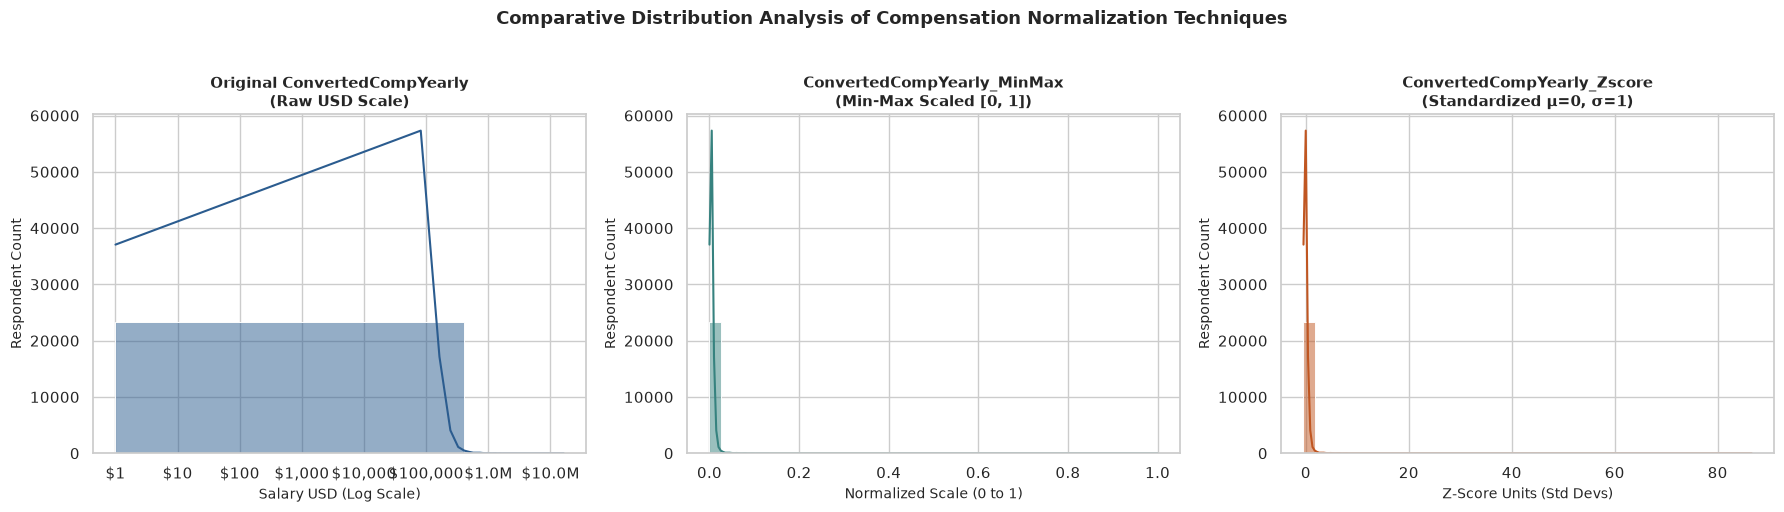

In [28]:
## Write your code here
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid", font="sans-serif")

# Set up 3 side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Original ConvertedCompYearly (Log Scale)
sns.histplot(
    data=df,
    x="ConvertedCompYearly",
    bins=40,
    kde=True,
    color="#2b5c8f",
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_title(
    "Original ConvertedCompYearly\n(Raw USD Scale)",
    fontsize=11,
    fontweight="bold",
)
axes[0].set_xlabel("Salary USD (Log Scale)", fontsize=10)
axes[0].set_ylabel("Respondent Count", fontsize=10)

# Format currency ticks ($1k, $10k, $100k, $1M)
formatter = ticker.FuncFormatter(
    lambda y, _: f"${y:,.0f}" if y < 1e6 else f"${y/1e6:,.1f}M"
)
axes[0].xaxis.set_major_formatter(formatter)

# 2. Min-Max Scaled [0, 1]
sns.histplot(
    data=df,
    x="ConvertedCompYearly_MinMax",
    bins=40,
    kde=True,
    color="#36827f",
    ax=axes[1],
)
axes[1].set_title(
    "ConvertedCompYearly_MinMax\n(Min-Max Scaled [0, 1])",
    fontsize=11,
    fontweight="bold",
)
axes[1].set_xlabel("Normalized Scale (0 to 1)", fontsize=10)
axes[1].set_ylabel("Respondent Count", fontsize=10)

# 3. Z-Score Standardized (Mean=0, Std=1)
sns.histplot(
    data=df,
    x="ConvertedCompYearly_Zscore",
    bins=40,
    kde=True,
    color="#c05621",
    ax=axes[2],
)
axes[2].set_title(
    "ConvertedCompYearly_Zscore\n(Standardized μ=0, σ=1)",
    fontsize=11,
    fontweight="bold",
)
axes[2].set_xlabel("Z-Score Units (Std Devs)", fontsize=10)
axes[2].set_ylabel("Respondent Count", fontsize=10)

plt.suptitle(
    "Comparative Distribution Analysis of Compensation Normalization Techniques",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
